In [1]:
#%%
from attack_utils import *
from matplotlib import pyplot as plt

In [2]:
which_dataset = 4    # 'iris = 0', 'crop = 1', 'adult = 2', 'breast = 3', 'nursery = 4', 'mushroom = 5', 'bc-tcga = 6', 'digits = 7'
which_model = 2    # 'Decision_Tree = 0', 'Logistic_Regression = 1', 'Multinomial_Naive_Bayes = 2', 'K_Nearest_Neeighbor = 3', 'Random_Forest = 4', 'Multilayer_Perceptron = 5'
explanation_tool = 0 # 'Lime = 0', 'Shap = 1'
how_many_sets = 10 # This is the number of auxiliary datasets to experiment on. Lower the number for lowering the runtime.
sample_set_sizes = [3] # (list of n values from the paper) Size of auxiliary dataset (per class) in a list format
nfe = [1] # (list of k values from the paper) Number of features explored in a list format
query_limit = [500] # (list of Q values from the paper) Number of queries allowed for traversal

In [6]:
## Shorten nfe for shorter runtime
results, other_args = run_attack_auto(which_dataset, which_model, explanation_tool, how_many_sets, sample_set_sizes, nfe, query_limit, False)

DATASET 4 2
Train results
[[3225    2    1]
 [   0 1985 1213]
 [   0 1159 2135]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3228
           1       0.63      0.62      0.63      3198
           2       0.64      0.65      0.64      3294

    accuracy                           0.76      9720
   macro avg       0.76      0.76      0.76      9720
weighted avg       0.76      0.76      0.76      9720

Test results
[[634   0   0]
 [  0 409 236]
 [  0 242 423]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       634
           1       0.63      0.63      0.63       645
           2       0.64      0.64      0.64       665

    accuracy                           0.75      1944
   macro avg       0.76      0.76      0.76      1944
weighted avg       0.75      0.75      0.75      1944

Model test accuracy:  0.7541 

Dataset:   Nursery
ML Model:  Multinomial Naive Bayes
LIME is the e

UnboundLocalError: local variable 'tmp' referenced before assignment

In [3]:
accuracies, rtest_sims, acc_baseline, rtest_sims_baseline, _, _ = run_attack_auto_compare(
                which_dataset, 
                which_model, 
                explanation_tool, 
                how_many_sets, 
                sample_set_sizes, 
                nfe, 
                query_limit, 
                True,
                True
            )


DATASET 4 2
Train results
[[3225    2    1]
 [   0 1985 1213]
 [   0 1159 2135]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3228
           1       0.63      0.62      0.63      3198
           2       0.64      0.65      0.64      3294

    accuracy                           0.76      9720
   macro avg       0.76      0.76      0.76      9720
weighted avg       0.76      0.76      0.76      9720

Test results
[[634   0   0]
 [  0 409 236]
 [  0 242 423]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       634
           1       0.63      0.63      0.63       645
           2       0.64      0.64      0.64       665

    accuracy                           0.75      1944
   macro avg       0.76      0.76      0.76      1944
weighted avg       0.75      0.75      0.75      1944

Model test accuracy:  0.7541 

Dataset:   Nursery
ML Model:  Multinomial Naive Bayes
LIME is the e

In [ ]:
#print average similaties and accuracies for each explanation type and standard deviations
for etype in results:
    print(f"Explanation Type: {etype}")
    # print("Average Accuracy and Std Dev: ", np.mean(results[etype]['accuracies']), np.std(results[etype]['accuracies']))
    print("Average Similarity and Std Dev: ", np.mean(results[etype]['rtest_sims']), np.std(results[etype]['rtest_sims']))
    print()

In [ ]:
## Shorten nfe for shorter runtime
averages, similarities, _, _ = run_attack_auto(which_dataset, which_model, explanation_tool, how_many_sets, sample_set_sizes, nfe, query_limit, False)
print("Results Summary:")
print(np.average(similarities), np.std(similarities))

In [ ]:
#%% Show results
print("Results Summary:")
print(np.average(similarities), np.std(similarities))
#write results to a file
with open("results_summary.txt", "a") as f:
    f.write(f"Dataset: {which_dataset}, Model: {which_model}, Explanation Tool: {explanation_tool}\n")
    f.write(f"Average Similarity: {np.average(similarities)}, Std Dev: {np.std(similarities)}\n")


Run the attack notebook for all dataset/model combinations with a comparison to the Autolycus

In [9]:
# Run attack for all datasets and models, collect average similarities
import numpy as np

# Parameters for the attack
explanation_tool = 0  # Shap
how_many_sets = 10
sample_set_sizes = [3]
nfe = [1]
query_limit = [500]

# Results storage
all_results = []
baseline_results = []

In [10]:
import json
import os

# Loop through all datasets and models
n_datasets = 6  # 0-5
n_models = 6    # 0-5

checkpoint_path = "results_all_combinations_checkpoint.json"
output_path = "results_all_combinations.txt"

def write_results_file(path, main_results, base_results):
    with open(path, "w") as f:
        f.write("Dataset\tModel\tAvgSimilarity\tBaselineSimilarity\n")
        for main, base in zip(main_results, base_results):
            f.write(
                f"{main['dataset']}\t{main['model']}\t{main['avg_similarity']:.4f}\t{base['avg_similarity']:.4f}\n"
            )

def save_checkpoint(path, main_results, base_results):
    # Atomic write protects checkpoint integrity on interrupted execution.
    tmp_path = f"{path}.tmp"
    payload = {
        "all_results": main_results,
        "baseline_results": base_results
    }
    with open(tmp_path, "w") as f:
        json.dump(payload, f, indent=2)
    os.replace(tmp_path, path)

# Resume from checkpoint if available.
if os.path.exists(checkpoint_path):
    with open(checkpoint_path, "r") as f:
        saved = json.load(f)
    all_results = saved.get("all_results", all_results)
    baseline_results = saved.get("baseline_results", baseline_results)
    print(f"Loaded checkpoint with {len(all_results)} completed combinations.")
else:
    print("No checkpoint found. Starting a fresh run.")

completed_pairs = {(row["dataset"], row["model"]) for row in all_results}

print("Running attacks for all dataset and model combinations...\n")

try:
    for which_dataset in range(n_datasets):
        for which_model in range(n_models):
            if (which_dataset, which_model) in completed_pairs:
                print(f"Dataset: {which_dataset}, Model: {which_model}... already completed, skipping")
                continue

            try:
                print(f"Dataset: {which_dataset}, Model: {which_model}...", end=" ")

                # Using run_attack_auto_compare
                accuracies, rtest_sims, acc_baseline, rtest_sims_baseline, _, _ = run_attack_auto_compare(
                    which_dataset,
                    which_model,
                    explanation_tool,
                    how_many_sets,
                    sample_set_sizes,
                    nfe,
                    query_limit,
                    True
                )

                # Flatten lists if they are nested because argmaxing may return nested chunks
                flat_sims = [s for batch in rtest_sims for s in batch] if len(rtest_sims) > 0 and isinstance(rtest_sims[0], list) else rtest_sims
                avg_similarity = float(np.mean(flat_sims)) if len(flat_sims) > 0 else np.nan

                if rtest_sims_baseline:
                    flat_base = [s for batch in rtest_sims_baseline for s in batch] if len(rtest_sims_baseline) > 0 and isinstance(rtest_sims_baseline[0], list) else rtest_sims_baseline
                    avg_base_similarity = float(np.mean(flat_base)) if len(flat_base) > 0 else np.nan
                else:
                    avg_base_similarity = np.nan

                all_results.append({
                    "dataset": which_dataset,
                    "model": which_model,
                    "avg_similarity": avg_similarity
                })
                baseline_results.append({
                    "dataset": which_dataset,
                    "model": which_model,
                    "avg_similarity": avg_base_similarity
                })

                print(f"Avg Similarity: {avg_similarity:.4f} | Baseline: {avg_base_similarity:.4f}")
            except Exception as e:
                print(f"Error: {e}")
                all_results.append({"dataset": which_dataset, "model": which_model, "avg_similarity": np.nan})
                baseline_results.append({"dataset": which_dataset, "model": which_model, "avg_similarity": np.nan})
            finally:
                completed_pairs.add((which_dataset, which_model))
                save_checkpoint(checkpoint_path, all_results, baseline_results)
                write_results_file(output_path, all_results, baseline_results)
except KeyboardInterrupt:
    print("\nExecution interrupted. Progress was checkpointed.")

# Final write (same format, for convenience)
print("\n\nWriting final results to file...")
write_results_file(output_path, all_results, baseline_results)
print(f"Results written to {output_path}")
print(f"Checkpoint saved at {checkpoint_path}")

Loaded checkpoint with 36 completed combinations.
Running attacks for all dataset and model combinations...

Dataset: 0, Model: 0... already completed, skipping
Dataset: 0, Model: 1... already completed, skipping
Dataset: 0, Model: 2... already completed, skipping
Dataset: 0, Model: 3... already completed, skipping
Dataset: 0, Model: 4... already completed, skipping
Dataset: 0, Model: 5... already completed, skipping
Dataset: 1, Model: 0... already completed, skipping
Dataset: 1, Model: 1... already completed, skipping
Dataset: 1, Model: 2... already completed, skipping
Dataset: 1, Model: 3... already completed, skipping
Dataset: 1, Model: 4... already completed, skipping
Dataset: 1, Model: 5... already completed, skipping
Dataset: 2, Model: 0... already completed, skipping
Dataset: 2, Model: 1... already completed, skipping
Dataset: 2, Model: 2... already completed, skipping
Dataset: 2, Model: 3... already completed, skipping
Dataset: 2, Model: 4... already completed, skipping
Dataset

In [11]:
results_df = pd.DataFrame(all_results)
results_pivot = results_df.pivot(index='dataset', columns='model', values='avg_similarity')
print(len(results_pivot.index))
print(results_pivot.index)


6
Int64Index([0, 1, 2, 3, 4, 5], dtype='int64', name='dataset')


In [12]:
from turtle import ht

import pandas as pd
import numpy as np

# Create DataFrames from the collected results dynamically
dataset_names = ['iris', 'crop', 'adult', 'breast', 'nursery', 'mushroom']
model_names = ['DT', 'LR', 'NB', 'KNN', 'RF', 'P']

# Results DataFrame (Main)
results_df = pd.DataFrame(all_results)
results_pivot = results_df.pivot(index='dataset', columns='model', values='avg_similarity')
results_pivot.index   = [dataset_names[i] for i in results_pivot.index]
results_pivot.columns = [model_names[c]   for c in results_pivot.columns]


# Baseline DataFrame
baseline_df_raw = pd.DataFrame(baseline_results)
baseline_df = baseline_df_raw.pivot(index='dataset', columns='model', values='avg_similarity')
baseline_df.index = [dataset_names[i] for i in baseline_df.index]
baseline_df.columns = [model_names[c] for c in baseline_df.columns]

print("\nResults Pivot Table (Main):")
display(results_pivot)

print("\nBaseline Pivot Table:")
display(baseline_df)

# Calculate Differences
diff_df = results_pivot - baseline_df
pct_change_df = (diff_df / baseline_df) * 100

# Professional Styling
# Find the largest absolute change to center the color scale at zero
v_limit = max(abs(diff_df.min().min()), abs(diff_df.max().max()), 0.001)

# --- Table 1: Final Results (Colored by Change Magnitude) ---
styled_results = results_pivot.style.background_gradient(
    cmap='RdYlGn', 
    axis=None, 
    gmap=diff_df, # Use the difference values for the background color
    vmin=-v_limit, 
    vmax=v_limit
).format(precision=4, na_rep="N/A").set_caption("Similarity Results (Colors = Change from Baseline)")

# --- Table 2: Percentage Change Table ---
styled_pct = pct_change_df.style.background_gradient(
    cmap='RdYlGn', 
    axis=None, 
    vmin=-10, # Intensity caps at +/- 10%
    vmax=10
).format("{:+.2f}%", na_rep="N/A").set_caption("Percentage Change vs Baseline")

# Display in Notebook
display(styled_results)
display(styled_pct)




Results Pivot Table (Main):


,DT,LR,NB,KNN,RF,P
iris,0.98663,0.97270,0.81364,0.97725,0.99545,NaN
crop,0.87995,0.84588,0.80198,0.68784,0.95330,0.67922
adult,0.77593,0.76828,0.96805,0.84258,0.85150,0.81443
breast,0.88590,0.88707,0.83412,0.91176,0.92446,0.98352
nursery,0.84747,0.93962,0.77367,0.61776,0.86809,0.85926
mushroom,0.82875,0.76240,0.84794,0.77004,0.81826,0.80738



Baseline Pivot Table:


,DT,LR,NB,KNN,RF,P
iris,0.84090,0.98180,0.54550,0.94089,0.96409,NaN
crop,0.84487,0.82040,0.78198,0.65139,0.93943,0.66469
adult,0.67745,0.74903,0.91499,0.85027,0.73304,0.63660
breast,0.78771,0.92588,0.95294,0.84823,0.86966,0.94705
nursery,0.83170,0.92541,0.77588,0.56604,0.83123,0.81970
mushroom,0.71584,0.63161,0.80960,0.72185,0.76241,0.78734


,DT,LR,NB,KNN,RF,P
iris,0.9866,0.9727,0.8136,0.9772,0.9954,N/A
crop,0.8800,0.8459,0.8020,0.6878,0.9533,0.6792
adult,0.7759,0.7683,0.9680,0.8426,0.8515,0.8144
breast,0.8859,0.8871,0.8341,0.9118,0.9245,0.9835
nursery,0.8475,0.9396,0.7737,0.6178,0.8681,0.8593
mushroom,0.8287,0.7624,0.8479,0.7700,0.8183,0.8074


,DT,LR,NB,KNN,RF,P
iris,+17.33%,-0.93%,+49.15%,+3.86%,+3.25%,N/A
crop,+4.15%,+3.11%,+2.56%,+5.60%,+1.48%,+2.19%
adult,+14.54%,+2.57%,+5.80%,-0.90%,+16.16%,+27.93%
breast,+12.47%,-4.19%,-12.47%,+7.49%,+6.30%,+3.85%
nursery,+1.90%,+1.54%,-0.28%,+9.14%,+4.43%,+4.83%
mushroom,+15.77%,+20.71%,+4.74%,+6.68%,+7.33%,+2.55%


In [14]:
# visualize results x axis is the explanation type, y axis is the similarity
import numpy as np
import matplotlib.pyplot as plt

# Resolve readable dataset/model names
dataset_dict, model_dict, exp_dict = load_experiment_dicts()
dataset_label = dataset_dict.get(which_dataset, f"Dataset {which_dataset}")
model_label = model_dict.get(which_model, f"Model {which_model}")

explanation_types = list(all_results.keys())
similarities = [np.mean(results[etype]['rtest_sims']) for etype in explanation_types]

# each bar should have different pastel color
colors = ['#AEC6CF', '#77DD77', '#FFB347', '#B39EB5', '#FF6961', '#FDFD96', '#CB99C9', '#CFCFC4', '#F49AC2', '#C23B22']

plt.figure(figsize=(9,5))
plt.bar(explanation_types, similarities, color=colors[:len(explanation_types)])

# put the value on top of each bar
for i, v in enumerate(similarities):
    plt.text(i, v + 0.001, f"{v:.3f}", ha='center', fontweight='bold')

# Add labels and title (include dataset and model)
plt.xlabel('Explanation Type')
plt.ylabel('Average Similarity')  # focus on 0.5 to 1.0 range
plt.ylim(0.5, 1.0)
plt.title(f'Average Similarity by Explanation Type\nDataset: {dataset_label} | Model: {model_label}', fontsize=12)

# Add small info string with other parameters below the chart
info_str = f"sets={how_many_sets} | sample_set_sizes={sample_set_sizes} | nfe={nfe} | ql={query_limit}"
ax = plt.gca()
ax.text(0.99, -0.12, info_str, ha='right', va='top', transform=ax.transAxes, fontsize=9,
        bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'))

plt.tight_layout()
plt.show()

AttributeError: 'list' object has no attribute 'keys'

In [3]:
# ============== Query-budget sweep: per-dataset budgets (iris/breast 0-100, rest 0-1000) ==============
# LIME3 (ours) vs Autolycus baseline across query budgets. Stores the RAW per-set fidelities per Q so
# plotting stays decoupled (next cell). Checkpointed per combo -> safe to interrupt and resume.
# NOTE: long run (len(datasets) x len(models) x 5 budgets x SWEEP_SETS). Trim the lists to shorten.
import json, os
import numpy as np

SWEEP_ET       = 0            # 0 = LIME (LIME3 vs base LIME), 1 = SHAP
SWEEP_SETS     = 10           # how_many_sets (averaged)
SWEEP_SIZE     = [3]          # sample_set_sizes (seeds per class)  -- keep single-element
SWEEP_NFE      = [1]          # nfe (k)                              -- keep single-element
SWEEP_SEED     = 0            # fixed seed -> reproducible
SWEEP_DATASETS = [0, 1, 4]   # iris crop adult breast nursery mushroom
SWEEP_MODELS   = [0, 1, 2, 3, 4, 5]   # DT LR NB KNN RF P

def budget_for(ds):
    # iris(0) / breast(3) -> 0..100 ; everything else -> 0..1000  (Autolycus-style)
    return [0, 25, 50, 75, 100] if ds in (0, 3) else [0, 100, 250, 500, 1000]

sweep_ckpt = "sweep_curves_checkpoint.json"
sweep = json.load(open(sweep_ckpt)) if os.path.exists(sweep_ckpt) else {}
print(f"resuming: {len(sweep)} combos already done" if sweep else "fresh sweep")

for ds in SWEEP_DATASETS:
    q_list = budget_for(ds)
    for m in SWEEP_MODELS:
        key = f"{ds}_{m}"
        if key in sweep:
            print(key, "done, skip"); continue
        try:
            # sims[h] / sims_b[h] are the SWEEP_SETS fidelities at q_list[h] (single nfe & size)
            _, sims, _, sims_b, _, _ = run_attack_auto_compare(
                ds, m, SWEEP_ET, SWEEP_SETS, SWEEP_SIZE, SWEEP_NFE, q_list, False, seed=SWEEP_SEED)
            sweep[key] = {"q": q_list,
                          "main": [[float(x) for x in s] for s in sims],
                          "base": [[float(x) for x in s] for s in sims_b]}
            print(f"  {key} main means:", [round(float(np.mean(s)), 3) for s in sims])
            print(f"  {key} main stds:", [round(float(np.std(s)), 3) for s in sims])
        except Exception as e:
            print(f"  {key} FAILED: {type(e).__name__}: {e}")
            sweep[key] = {"q": q_list, "main": None, "base": None}
        json.dump(sweep, open(sweep_ckpt, "w"))   # checkpoint after each combo
print("sweep complete ->", sweep_ckpt)


fresh sweep
DATASET 0 0
Train results
[[37  0  0]
 [ 0 34  0]
 [ 0  0 41]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        37
           1       1.00      1.00      1.00        34
           2       1.00      1.00      1.00        41

    accuracy                           1.00       112
   macro avg       1.00      1.00      1.00       112
weighted avg       1.00      1.00      1.00       112

Test results
[[ 6  0  0]
 [ 0 10  1]
 [ 0  0  5]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         6
           1       1.00      0.91      0.95        11
           2       0.83      1.00      0.91         5

    accuracy                           0.95        22
   macro avg       0.94      0.97      0.95        22
weighted avg       0.96      0.95      0.96        22

Model test accuracy:  0.9545 

Dataset:   Iris
ML Model:  Decision Tree
LIME is the explanation tool currently in

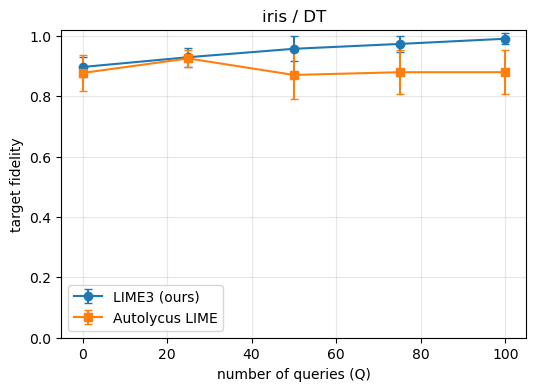

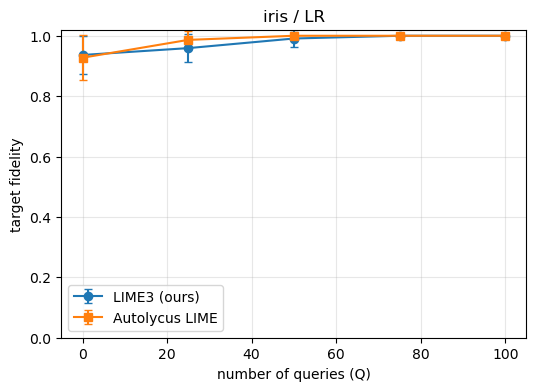

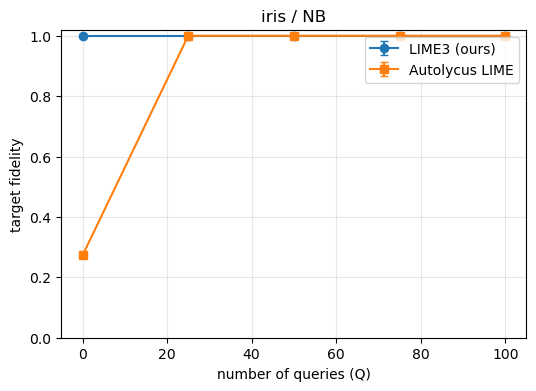

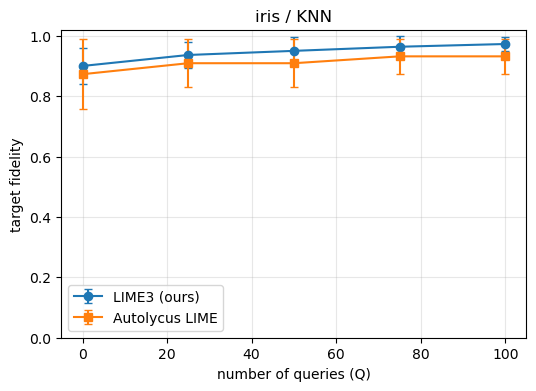

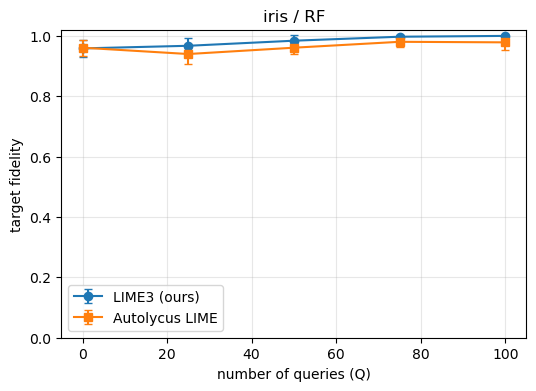

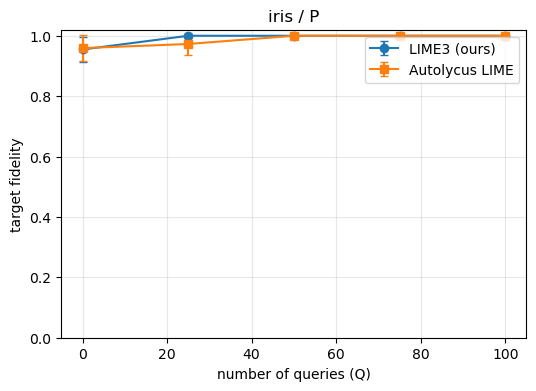

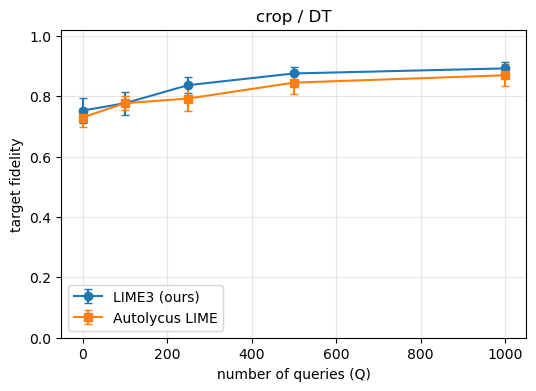

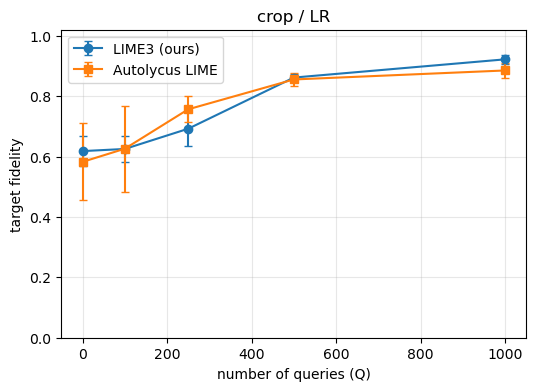

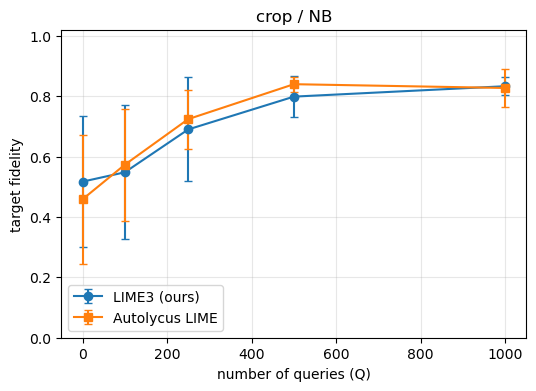

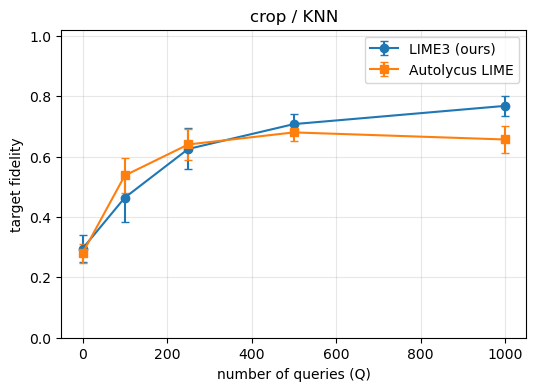

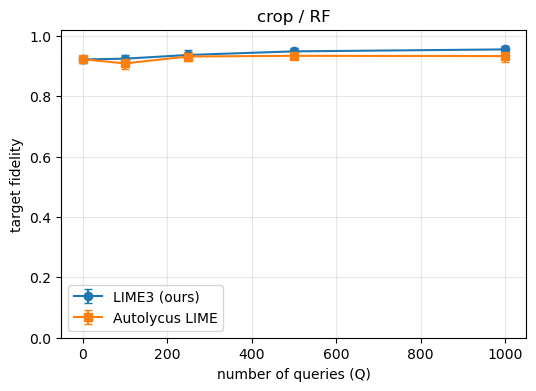

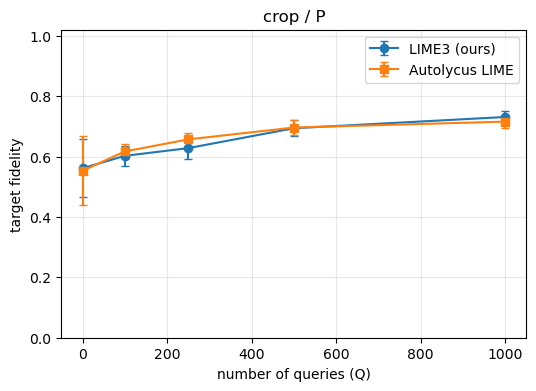

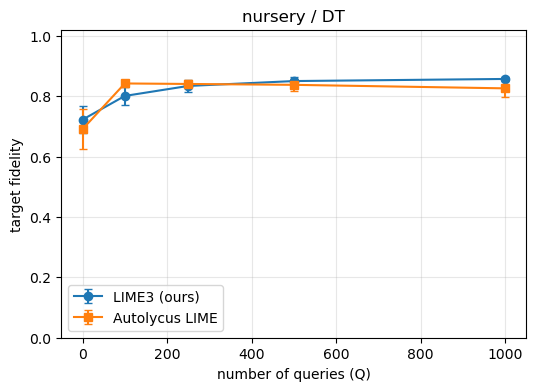

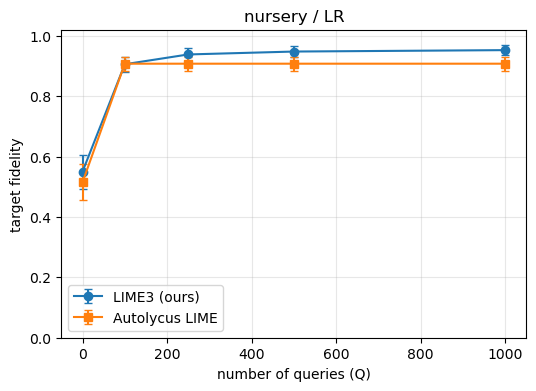

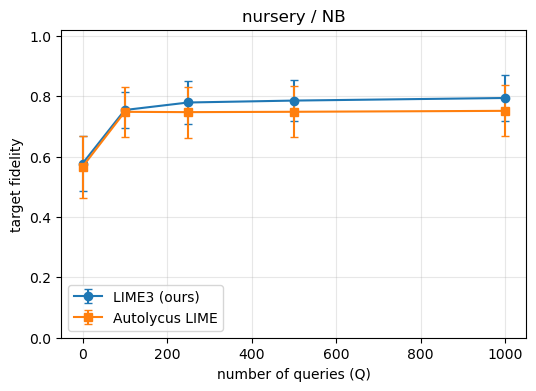

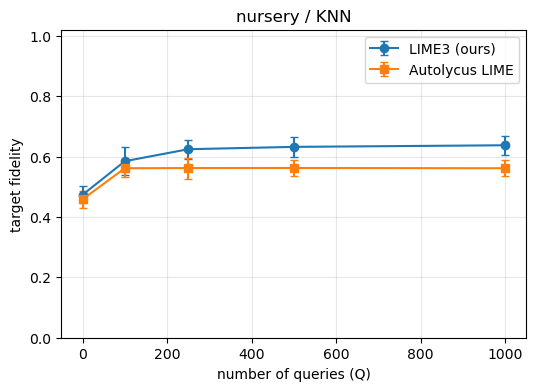

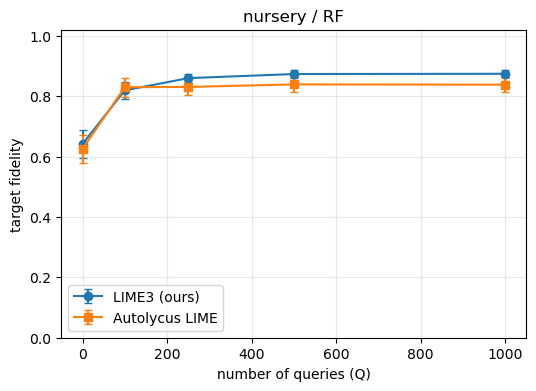

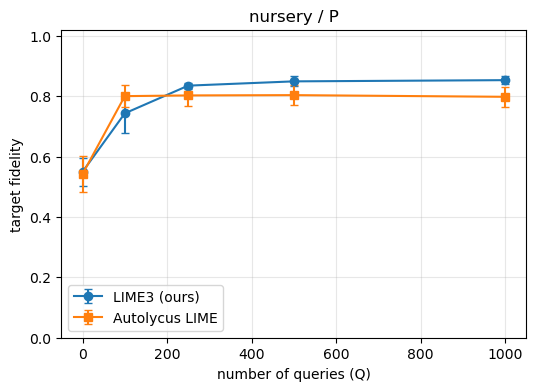

In [4]:
# ============== Plot fidelity vs queries (decoupled: reads the raw sweep checkpoint) ==============
import json, numpy as np, matplotlib.pyplot as plt

sweep = json.load(open("sweep_curves_checkpoint.json"))
dnames = ['iris', 'crop', 'adult', 'breast', 'nursery', 'mushroom']
mnames = ['DT', 'LR', 'NB', 'KNN', 'RF', 'P']
et = globals().get('SWEEP_ET', 0)
main_lbl = 'LIME3 (ours)' if et == 0 else 'SHAP3 (ours)'
base_lbl = 'Autolycus LIME' if et == 0 else 'Autolycus SHAP'

for key, r in sorted(sweep.items(), key=lambda kv: tuple(map(int, kv[0].split('_')))):
    if not r["main"]:
        continue
    ds, m = map(int, key.split("_"))
    q = r["q"]
    mm = [np.mean(s) for s in r["main"]]; ms = [np.std(s) for s in r["main"]]
    bm = [np.mean(s) for s in r["base"]]; bs = [np.std(s) for s in r["base"]]
    plt.figure(figsize=(6, 4))
    plt.errorbar(q, mm, yerr=ms, marker='o', capsize=3, label=main_lbl)
    plt.errorbar(q, bm, yerr=bs, marker='s', capsize=3, label=base_lbl)
    plt.xlabel('number of queries (Q)'); plt.ylabel('target fidelity')
    plt.title(f'{dnames[ds]} / {mnames[m]}')
    plt.legend(); plt.grid(alpha=0.3); plt.ylim(0, 1.02)
    plt.show()


In [5]:
#run attack with different models and datasets and different top_exp values
#keep the average similarity results for each combination and visualize them later
explanation_tool = 1 # 'Lime = 0', 'Shap = 1'
how_many_sets = 10 # This is the number of auxiliary datasets to experiment on. Lower the number for lowering the runtime.
sample_set_sizes = [5] # (list of n values from the paper) Size of auxiliary dataset (per class) in a list format
nfe = [3] # (list of k values from the paper) Number of features explored in a list format
query_limit = [500] # (list of Q values from the paper) Number of queries allowed for traversal
import numpy as np
for which_dataset in [2]:
    for which_model in range(4,6):
        for top_exp in [1,3,5,7]:
            results, other_args = run_attack_auto_v2(which_dataset, which_model, explanation_tool, how_many_sets, sample_set_sizes, nfe, query_limit, False, top_exp)
            print(f"Dataset: {which_dataset}, Model: {which_model}, Top Exp: {top_exp}")
            for etype in results.keys():
                #save the results to use later
                np.save(f"results/results_dataset{which_dataset}_model{which_model}_topexp{top_exp}_etype{etype}.npy", results[etype]['rtest_sims'])
                print(f"Explanation Type: {etype}")
                print("Average Similarity and Std Dev: ", np.mean(results[etype]['rtest_sims']), np.std(results[etype]['rtest_sims']))
        print()

Train results
[[17890   616]
 [ 1616  4298]]
              precision    recall  f1-score   support

           0       0.92      0.97      0.94     18506
           1       0.87      0.73      0.79      5914

    accuracy                           0.91     24420
   macro avg       0.90      0.85      0.87     24420
weighted avg       0.91      0.91      0.91     24420

Test results
[[3464  223]
 [ 454  743]]
              precision    recall  f1-score   support

           0       0.88      0.94      0.91      3687
           1       0.77      0.62      0.69      1197

    accuracy                           0.86      4884
   macro avg       0.83      0.78      0.80      4884
weighted avg       0.86      0.86      0.86      4884

Model test accuracy:  0.8614 



Dataset:   Adult Income
ML Model:  Random Forest
SHAP is the explanation tool currently in use

Lower bounds:  [126]  Upper bounds:  [626] 

-----The attack starts here!-----

samples mega length: 10
0
Number of top features allowed to be explored (k): 3

Number of samples per class (n): 5

Processing sample set 0
Processing explanation type: vanilla
Dataset name in traverse_explanations_SHAP3: adult
1 2 3 4 Training a surrogate model for explanation type: vanilla and query limit: 500
Fitting surrogate model...
500 500
Fitting surrogate model...
500 500
Fitting surrogate model...
500 500
Fitting surrogate model...
500 500
Fitting surrogate model...
500 500
Fitting surrogate model...
500 500
Fitting surrogate model...
500 500
Fitting surrogate model...
500 500
Fitting surrogate model...
500 500
Fitting surrogate model...
500 500
Sample set 0 , n_queries = 500 , Similarities by type:

Processing sample set 1
Processing explanation type: vanilla
Dataset name in traverse_explanations_SHAP3

KeyboardInterrupt: 

In [ ]:
# read saved results and visualize. Group by dataset and model, x axis is top_exp, y axis is average similarity, different lines for different explanation types
import numpy as np
import matplotlib.pyplot as plt 
which_dataset = 2    
explanation_types = ["vanilla", "topk", "random", "zero"]

for which_model in range(6):
    top_exps = [1,3, 5, 7]
    for etype in explanation_types:
        avg_similarities = []
        for top_exp in top_exps: #results are saved in "results" folder with this naming convention                  
            try:
                sims = np.load(f"results/results_dataset{which_dataset}_model{which_model}_topexp{top_exp}_etype{etype}.npy")
            except FileNotFoundError:
                avg_similarities.append(0)
                continue
            avg_similarities.append(np.mean(sims))
        plt.plot(top_exps, avg_similarities, marker='o', label=etype)
    plt.xlabel('Top Explanations Used')
    plt.ylabel('Average Similarity')
    plt.title(f'Dataset: {which_dataset}, Model: {which_model}')
    plt.legend()
    plt.show()

In [ ]:
import glob
import os
import re
import numpy as np
import matplotlib.pyplot as plt

# Read results for dataset 1, grouped by model
# X-axis: top_exp values, Y-axis: average similarity, different lines for each explanation type

dataset_idx = 1
top_exps_to_read = [1, 3, 5, 7, 10]
explanation_types = ['vanilla', 'topk', 'random', 'zero', 'hybrid']

# Find all result files for dataset 1
pattern = f"results_dataset{dataset_idx}_model*_topexp*_etype*.npy"
files = glob.glob(pattern)
print(f"Found {len(files)} result files for dataset {dataset_idx}")

# Parse filenames to organize data
# data[model_idx][etype] = {top_exp: avg_similarity}
data = {}
available_etypes = set()
available_models = set()

rx = re.compile(r"results_dataset(\d+)_model(\d+)_topexp(\d+)_etype(.+)\.npy")
for fpath in files:
    fname = os.path.basename(fpath)
    m = rx.match(fname)
    if not m:
        continue
    _, model_s, topexp_s, etype = m.groups()
    model_idx = int(model_s)
    topexp = int(topexp_s)
    
    available_models.add(model_idx)
    available_etypes.add(etype)
    
    try:
        sims = np.load(fpath, allow_pickle=True)
        sims = np.asarray(sims).ravel()
        if len(sims) == 0:
            continue
        avg_sim = float(np.mean(sims))
        data.setdefault(model_idx, {}).setdefault(etype, {})[topexp] = avg_sim
    except Exception as e:
        print(f"Failed to load {fpath}: {e}")

if len(data) == 0:
    print("No data loaded.")
else:
    available_models_sorted = sorted(available_models)
    available_etypes_sorted = sorted(available_etypes)
    
    # Plot: one subplot per model
    n_models = len(available_models_sorted)
    n_cols = 2
    n_rows = (n_models + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows))
    axes = axes.ravel() if n_models > 1 else [axes]
    
    for idx, model_idx in enumerate(available_models_sorted):
        ax = axes[idx]
        for etype in available_etypes_sorted:
            sim_values = []
            topexp_values = []
            for te in top_exps_to_read:
                if te in data.get(model_idx, {}).get(etype, {}):
                    topexp_values.append(te)
                    sim_values.append(data[model_idx][etype][te])
            
            if len(sim_values) > 0:
                ax.plot(topexp_values, sim_values, marker='o', label=etype, linewidth=2)
        
        ax.set_xlabel('Top Explanations (top_exp)')
        ax.set_ylabel('Average Similarity')
        ax.set_title(f'Dataset {dataset_idx}, Model {model_idx}')
        ax.legend()
        ax.grid(True, alpha=0.3)
    
    # Hide unused subplots
    for idx in range(n_models, len(axes)):
        axes[idx].set_visible(False)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nAvailable explanation types: {sorted(available_etypes_sorted)}")
    print(f"Available models: {sorted(available_models_sorted)}")

In [ ]:
#Visualize the saved results
import numpy as np
import matplotlib.pyplot as plt
for which_dataset in range(6):
    for which_model in range(6):
        top_exp_values = [1, 3, 5, 7, 10]
        explanation_types = []
        avg_similarities = {top_exp: [] for top_exp in top_exp_values}
        for top_exp in top_exp_values:
            for etype in ['vanilla', 'shap', 'lime']:
                try:
                    sims = np.load(f"results_dataset{which_dataset}_model{which_model}_topexp{top_exp}_etype{etype}.npy")
                    explanation_types.append(etype)
                    avg_similarities[top_exp].append(np.mean(sims))
                except FileNotFoundError:
                    continue
        #plotting
        x = np.arange(len(explanation_types))
        width = 0.15
        fig, ax = plt.subplots()
        for i, top_exp in enumerate(top_exp_values):
            ax.bar(x + i*width, avg_similarities[top_exp], width, label=f'Top Exp {top_exp}')
        ax.set_xlabel('Explanation Type')
        ax.set_ylabel('Average Similarity')
        ax.set_title(f'Average Similarity by Explanation Type\nDataset: {which_dataset}, Model: {which_model}')
        ax.set_xticks(x + width * (len(top_exp_values) - 1) / 2)
        ax.set_xticklabels(explanation_types)
        ax.legend()
        plt.show()

In [ ]:
# ...existing code...
def _flatten_and_stats(mat3d):
    """Convert nested list (dims x rows x cols) to numpy and return mean/std."""
    arr = np.array(mat3d, dtype=float)
    if arr.size == 0:
        return float('nan'), float('nan')
    return float(np.nanmean(arr)), float(np.nanstd(arr))


def sweep_top_exp(wd=which_dataset, wm=which_model, et=explanation_tool, hms=how_many_sets, sss=sample_set_sizes, nfe=nfe, ql=query_limit, so=False, top_exp_list=[1,3,5,10]):
    """
    Run run_attack_auto_v2 for each value in top_exp_list and return summary metrics.
    Returns dict: {top_exp: {'acc_mean':..., 'acc_std':..., 'sim_mean':..., 'sim_std':..., 'raw': (accuracies, sims)}}
    """
    results = {}
    for te in top_exp_list:
        print(f"\nRunning attack with top_exp = {te}")
        accs, sims, smega, other = run_attack_auto_v2(which_dataset, which_model, explanation_tool, how_many_sets, sample_set_sizes, nfe, query_limit, False, top_exp=te)
        acc_mean, acc_std = _flatten_and_stats(accs)
        sim_mean, sim_std = _flatten_and_stats(sims)
        results[te] = {
            'acc_mean': acc_mean,
            'acc_std': acc_std,
            'sim_mean': sim_mean,
            'sim_std': sim_std,
            'raw': (accs, sims, smega, other)
        }
        print(f"top_exp={te} -> acc_mean={acc_mean:.4f}, acc_std={acc_std:.4f}, sim_mean={sim_mean:.4f}, sim_std={sim_std:.4f}")
    return results
# ...existing code...

In [ ]:
# from attack_utils import sweep_top_exp
top_values = [1]
res = sweep_top_exp(top_exp_list=top_values)

In [ ]:
# Inspect results
print("\nSummary of results:")
print("TopExp\tAccMean\tSimMean\tSimStd")
for te, stats in res.items():
    print(te, stats['acc_mean'], stats['sim_mean'], stats['sim_std'])

In [ ]:
# write the results to results.txt file for later analysis add a header line
with open("results.txt", "a") as f:
    f.write("TopExp\tAccMean\tSimMean\n")
    for te, stats in res.items():
        f.write(f"{te}\t{stats['acc_mean']}\t{stats['sim_mean']}\n")